### Importing important libraries and datasets

In [249]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import OneHotEncoder

In [250]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

##### First 5 rows of the training dataset

In [251]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Information of the train dataset

In [252]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Creating a function to clean and encode our datasets

In [253]:
#Features we don't care about
drop_feat = np.array(['Name','Ticket','Cabin','Fare'])

In [254]:
#Premade encoder 
ohe = OneHotEncoder(sparse_output=False)

In [255]:
#Initializing the function
def clean(df):
    #Filling NaN values with the most likely value (that being 'S').
    df['Embarked'] = df['Embarked'].fillna('S')

    #Dropping unwanted features
    df = df.drop(drop_feat,axis = 1)

    #Encoding and concatenating the 3 unique values to the dataset as 3 new columns.
    df = pd.concat([df,pd.DataFrame(ohe.fit_transform(df[['Embarked']]))],axis = 1)

    #Renaming each column to correspond to the value they represent ('C','S' and 'Q'), axis = 1 implies renaming the columns, 0 would imply rows.
    df = df.rename({0:'C',1:'S',2:'Q'},axis = 1)

    #Dropping the 'Embarked' column as we don't need it anymore.
    df = df.drop(['Embarked'],axis = 1)

    #Filling NaN values in the 'Age' feature with the median of the same column.
    df['Age'] = df['Age'].fillna(df['Age'].median())

    #An empty array made to contain binary values, 0 indicating males and 1 indicating females.
    temp = np.array([])

    #Iterating through the values in the 'Sex' column of the datasets.
    for i in df['Sex']:

        #if female, then append a '0' into the temporary array.
        if i == 'female':
            temp = np.append(temp,0)

        #if female, then append a '0' into the temporary array.
        elif i == 'male':
            temp = np.append(temp,1)

    #Reinitializing the 'Sex' column from 'string' data type to a new 'float' binary column. 
    df['Sex'] = pd.DataFrame(temp)

    #Returning the new updated and cleaned dataset!
    return df

In [256]:
test_df = clean(test_df)
train_df = clean(train_df)

In [257]:
#The new updated dataset's first 5 rows
train_df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,C,S,Q
0,1,0,3,1.0,22.0,1,0,0.0,0.0,1.0
1,2,1,1,0.0,38.0,1,0,1.0,0.0,0.0
2,3,1,3,0.0,26.0,0,0,0.0,0.0,1.0
3,4,1,1,0.0,35.0,1,0,0.0,0.0,1.0
4,5,0,3,1.0,35.0,0,0,0.0,0.0,1.0


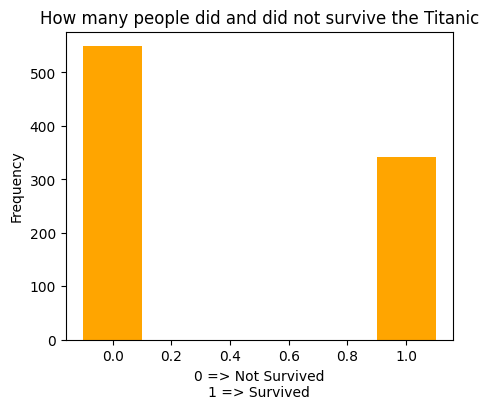

In [258]:
#Visualizing how many people did and did not survive the Titanic.
train_df['Survived'].plot(kind = 'hist',bins = [-0.5,0.5,1.5],rwidth = 0.2,color = 'orange',figsize = (5,4))
plt.title("How many people did and did not survive the Titanic")
plt.xlabel("0 => Not Survived\n1 => Survived")
plt.show()

#### Creating two subsets of the training dataset, one containing all those who lived and the other containing those who didn't

In [259]:
#sub-dataset containing all the survivors, having 
train_df_survived = pd.DataFrame({'Survived':np.array([]),
                                  'Pclass':np.array([]),
                                  'Sex':np.array([]),
                                  'Age':np.array([]),
                                  'SibSp':np.array([]),
                                  'Parch':np.array([]),
                                  'C':np.array([]),
                                  'S':np.array([]),
                                  'Q':np.array([])})

#sub-dataset containing all the survivors
train_df_not_survived = pd.DataFrame({'Survived':np.array([]),
                                  'Pclass':np.array([]),
                                  'Sex':np.array([]),
                                  'Age':np.array([]),
                                  'SibSp':np.array([]),
                                  'Parch':np.array([]),
                                  'C':np.array([]),
                                  'S':np.array([]),
                                  'Q':np.array([])})

In [260]:
#no. of elements in the 'Survived' column
n = train_df['Survived'].size

#Iterating through 'Survived' column as well as the index of the row.
for index,survived in zip(range(n),train_df['Survived']):

    #If survived, concatenate the passengers data into the newly made 'Survived' dataset
    if survived:
        passenger_data = train_df.iloc[[index]]
        train_df_survived = pd.concat([train_df_survived,passenger_data],ignore_index = True)

    #If not survived, concatenate the passengers data into the newly made 'Not Survived' dataset 
    elif not survived:
        passenger_data = train_df.iloc[[index]]
        train_df_not_survived = pd.concat([train_df_not_survived,passenger_data],ignore_index = True)        

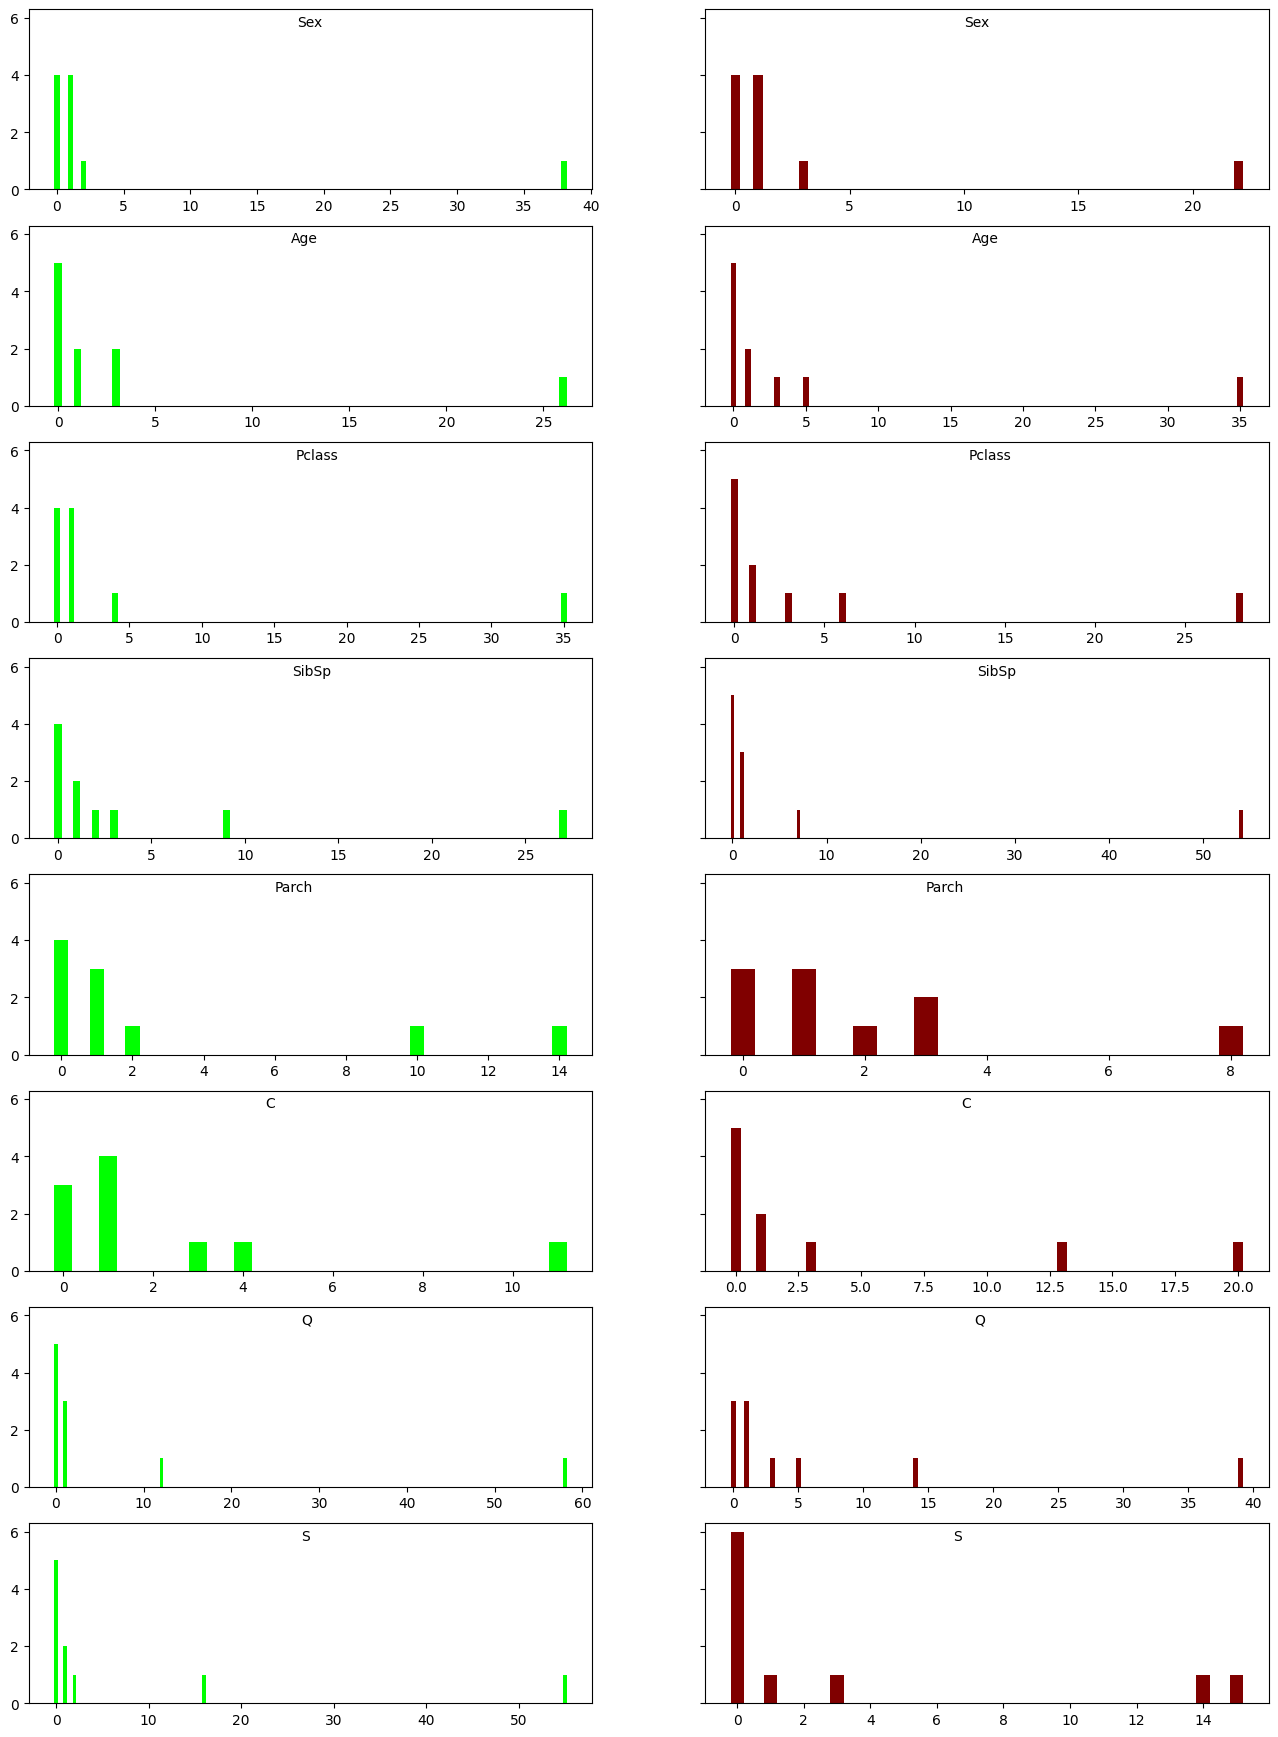

In [267]:
#List all features (Except PassengerId and Survived)
features = np.array(['Sex','Age','Pclass','SibSp','Parch','C','Q','S'])

#Creating 8*2 = 16 Subplots, first column shows histograms of features of the survivors dataset
#second column shows histograms of features of the not_survived dataset
fig,axes = plt.subplots(8,2,sharey=True,figsize = (16,22))

#Integer veriable to keep track of the features
count = 0
for i in range(8):
    for j in range(2):

        #if variable 'j' is 0(first column, i.e 'survived' dataset) 
        if j == 0:

            #Temporary variable 'data' to shorten the length of variables we will use ahead.
            data = train_df_survived.iloc[count]

            #Plot histogram of data
            axes[i,j].hist(data,bins = np.arange(data.min(),data.max() + 2) - 0.5,rwidth = 0.4,color = 'lime')

            #Add the name of the feature at the top-center of the subplot.
            axes[i,j].annotate(features[count],xy = ((data.min()+data.max()/2 - 1),5.7))

        
        #else the variable 'j' is 1(second column, i.e 'not_survived' dataset)
        else:
            #Temporary variable 'data' to shorten the length of variables we will use ahead.
            data = train_df_not_survived.iloc[count]

            #Plot histogram of data
            axes[i,j].hist(data,bins = np.arange(data.min(),data.max() + 2) - 0.5,rwidth = 0.4,color = 'maroon')

            #Add the name of the feature at the top-center of the subplot.
            axes[i,j].annotate(features[count],xy = ((data.min()+data.max()/2 - 1),5.7))
    count += 1
plt.show()

In [262]:
def predict_survivor(data):
    y = pd.DataFrame({'PassengerId':[],'Survived':[]})
    for pass_id,sex in zip(data['PassengerId'],data['Sex']):
        if sex == 0:
            temp = pd.DataFrame({'PassengerId':pass_id,'Survived':random.choices(population = [0,1], weights = [14.75,68.13])})
            y = pd.concat([y,temp],ignore_index=True)
        elif sex == 1:
            temp = pd.DataFrame({'PassengerId':pass_id,'Survived':random.choices(population = [0,1], weights = [85.24,31.87])})
            y = pd.concat([y,temp],ignore_index=True)
    return y.copy()

In [263]:
predict_survivor(test_df)

,PassengerId,Survived
0,892.0,1.0
1,893.0,1.0
2,894.0,0.0
3,895.0,1.0
4,896.0,0.0
...,...,...
413,1305.0,0.0
414,1306.0,1.0
415,1307.0,0.0
416,1308.0,0.0
